In [2]:
import os
os.chdir('../../..')

In [8]:
import numpy as np
import polars as pl

from scipy.spatial.distance import squareform
import plotly.graph_objects as go
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage as scipy_linkage, dendrogram
from scipy.cluster.hierarchy import cophenet, fcluster
from scipy.sparse.csgraph import laplacian
from scipy.linalg import eigh
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.spatial.distance import pdist, squareform

from src.datasets import MaterialsProject

from scripts.materials_project.evaluation_pipeline import (run_evaluation, 
                                                           hierachial_clustering, 
                                                           get_overall_chemical_coherence, 
                                                           get_distance_matrices,
                                                           build_invariant_matrix
                                                           )
from src.helper_functions import create_chemiscope_viewer

In [3]:
# mp = MaterialsProject()
# df = mp.load(force_fetch=True, limit=None)

In [4]:
mp = MaterialsProject(add_soap=True, add_acsf=False, sampling_strategy="stratified", stratify_on=["band_gap", "energy_above_hull"])
df = mp.load(limit=1000)

2026-03-31 19:22:14.220 | INFO     | src.datasets:load:1055 - Loading full cached Parquet data from data/Materials Project/materials.parquet...
2026-03-31 19:22:15.145 | INFO     | src.datasets:load:1085 - Sampling 1000 rows using stratified strategy...
2026-03-31 19:22:15.363 | INFO     | src.datasets:load:1102 - Computing descriptors on sampled subset (1000 rows) and saving to tagged cache: sample_n1000_seed40_stratified
2026-03-31 19:22:15.364 | INFO     | src.datasets:_add_descriptors:1346 - Ignoring output_tag=sample_n1000_seed40_stratified since descriptors are not saved to disk.
2026-03-31 19:22:15.364 | INFO     | src.datasets:_add_descriptors:1349 - Extracting unique elements from formulas...
2026-03-31 19:22:35.746 | INFO     | src.datasets:_add_descriptors:1359 - Found 85 unique elements. Warning: Feature vectors will be massive.
2026-03-31 19:22:35.763 | INFO     | src.datasets:_add_descriptors:1390 - Computing SOAP chunk 0 (0 to 1000)...
2026-03-31 19:22:38.709 | SUCCESS  

Silhouette Score: 0.5141
Davies-Bouldin Score: 0.6076


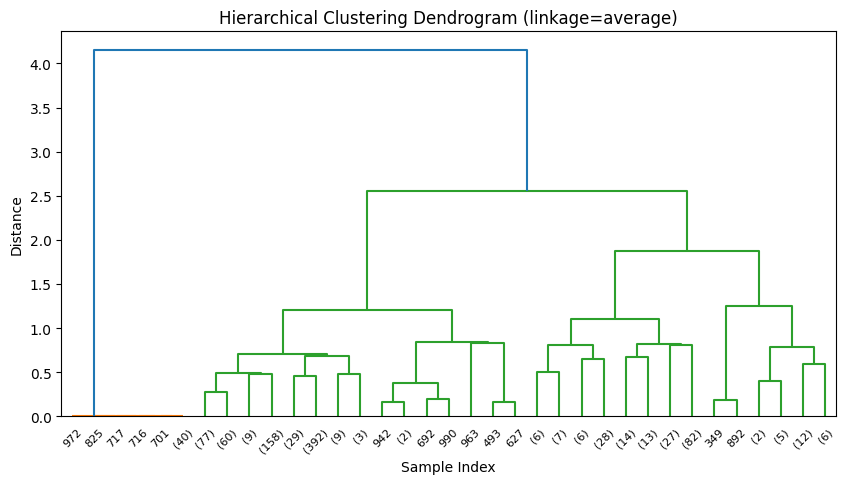

In [23]:
linkage = 'average'
feature_keys = ['avg_neighbor_dist']
raw_matrix = build_invariant_matrix(df, aggregated=True, feature_keys=feature_keys)
scaler = StandardScaler()
scaled_matrix = scaler.fit_transform(np.array(raw_matrix))

# 2. Compute Distances and Linkage
dist_condensed = pdist(scaled_matrix, metric='euclidean')
Z = scipy_linkage(dist_condensed, method=linkage)
k = 7
labels = fcluster(Z, k, criterion='maxclust')
sil = silhouette_score(scaled_matrix, labels)
db = davies_bouldin_score(scaled_matrix, labels)

print(f"Silhouette Score: {sil:.4f}")
print(f"Davies-Bouldin Score: {db:.4f}")
# 3. Plot Dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='level', p=5)
plt.title(f'Hierarchical Clustering Dendrogram (linkage={linkage})')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

# 4. Create Chemiscope Viewer
df = df.with_columns(pl.Series(name='cluster', values=labels))

In [21]:
create_chemiscope_viewer(df,  squareform(dist_condensed), labels=labels, reduction_method='t-SNE')

Running t-SNE dimensionality reduction...
Converting Pymatgen structures to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: materials_t-SNE_clustering.json
If the viewer does not open automatically, run `chemiscope show materials_t-SNE_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - SOAP t-SNE Clustering'}, settings={'map': {'x': {'propert…

In [8]:
dist_matrix = distance_matrices['invariant_complete_aggregated']
condensed_dist = squareform(dist_matrix)
reduction_technique = 'PCA'
linkage_type = 'complete'

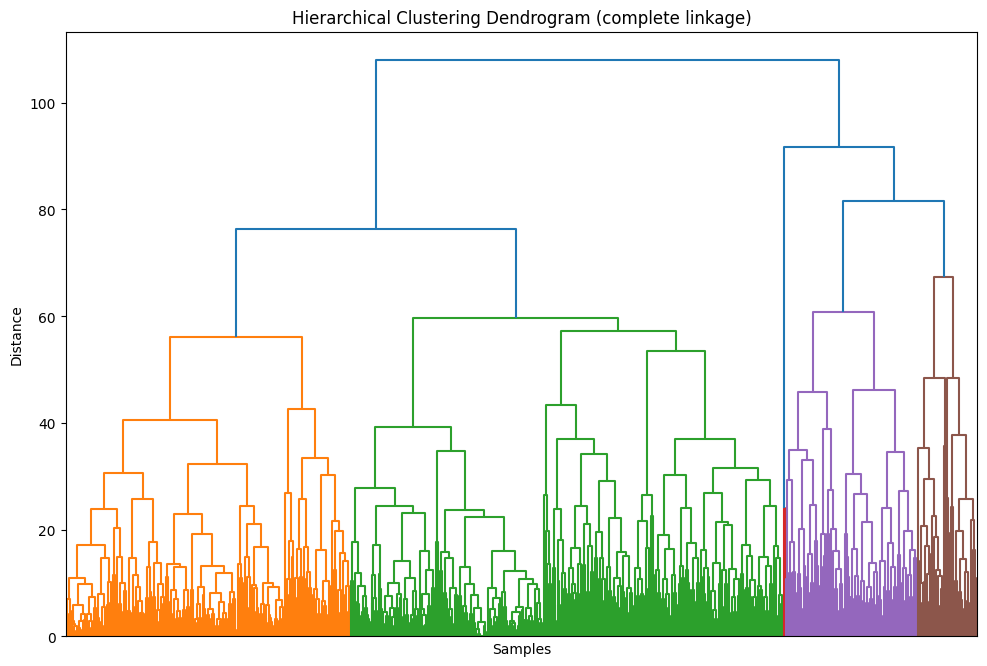

In [ ]:
#dict_keys(['soap_raw', 'soap_pca', 'soap_tsne', 'soap_umap', 'soap_isomap', 'invariant_avg_aggregated', 'invariant_complete_aggregated', 'invariant_riemann', 'invariant_grassmann', 'invariant_wasserstein']) for distance_matrices.keys()

dist_matrix = distance_matrices['invariant_complete_aggregated']
condensed_dist = squareform(dist_matrix)
linkage_type = 'complete'

Z = linkage(condensed_dist, method=linkage_type)
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.title(f"Hierarchical Clustering Dendrogram ({linkage_type} linkage)")
plt.tight_layout()
plt.xticks([])
plt.savefig("figures/materials/clustering/hierarchical/invariant_features.png", dpi=300)
plt.show()

Z = linkage(condensed_dist, method=linkage_type)
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.title(f"Hierarchical Clustering Dendrogram ({linkage_type} linkage)")
plt.tight_layout()
plt.xticks([])
plt.savefig("figures/materials/clustering/hierarchical/invariant_features.png", dpi=300)
plt.show()

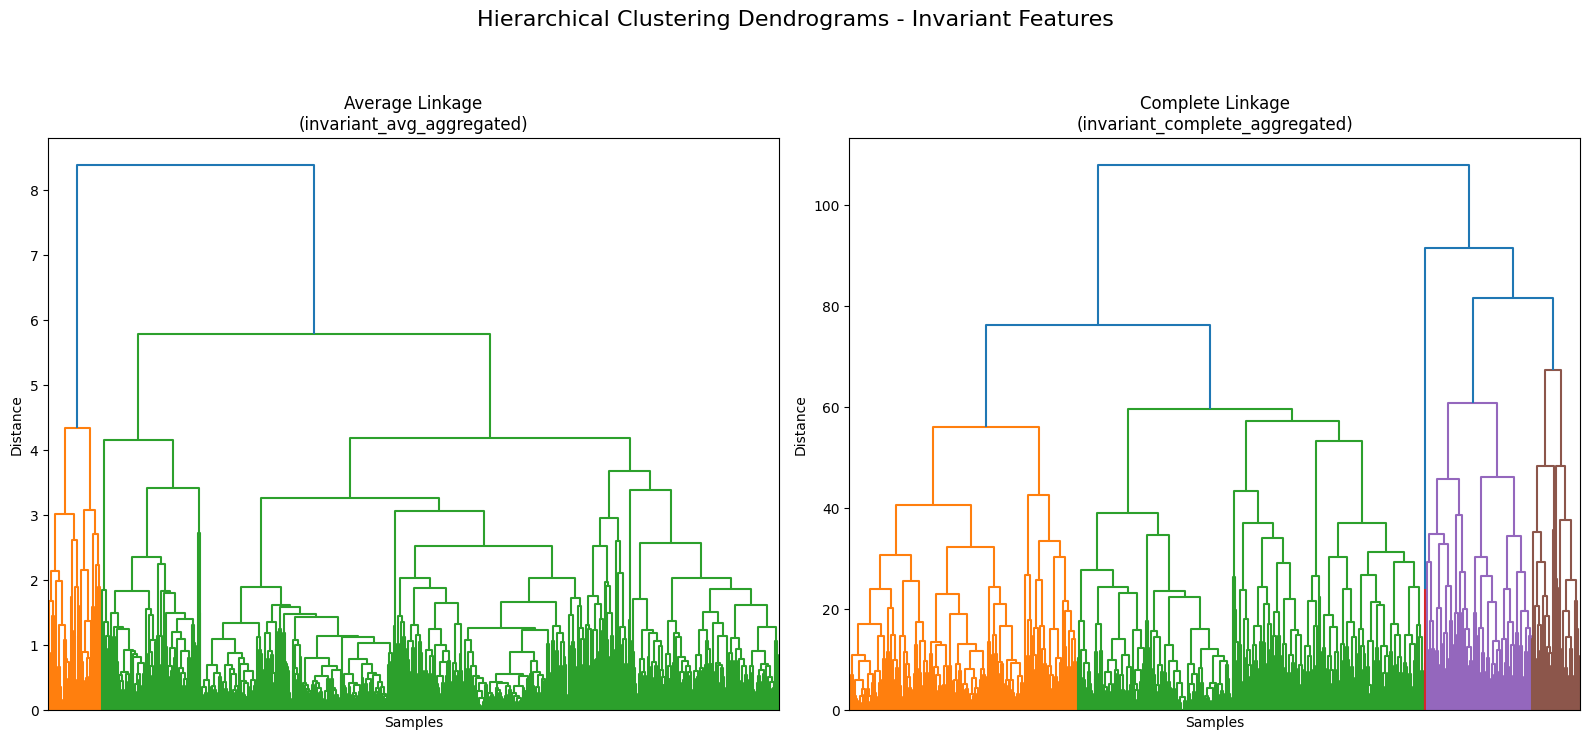

In [10]:
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram

# Create a 1x2 subplot grid
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Subplot 1: Average Linkage ---
dist_avg = distance_matrices['invariant_avg_aggregated']
# Use checks=False to prevent errors from tiny floating point inaccuracies
condensed_avg = squareform(dist_avg, checks=False) 
Z_avg = linkage(condensed_avg, method='average')

dendrogram(Z_avg, ax=axes[0], no_labels=True)
axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Distance")
axes[0].set_title("Average Linkage\n(invariant_avg_aggregated)", fontsize=12)
axes[0].set_xticks([]) # Hides the crowded sample labels

# --- Subplot 2: Complete Linkage ---
dist_comp = distance_matrices['invariant_complete_aggregated']
condensed_comp = squareform(dist_comp, checks=False)
Z_comp = linkage(condensed_comp, method='complete')

dendrogram(Z_comp, ax=axes[1], no_labels=True)
axes[1].set_xlabel("Samples")
axes[1].set_ylabel("Distance")
axes[1].set_title("Complete Linkage\n(invariant_complete_aggregated)", fontsize=12)
axes[1].set_xticks([])

# --- Final Layout & Saving ---
plt.suptitle("Hierarchical Clustering Dendrograms - Invariant Features", fontsize=16, y=1.05)
plt.tight_layout()

# Save the combined figure
plt.savefig("figures/materials/clustering/hierarchical/invariant_features_subplots.png", dpi=300, bbox_inches="tight")
plt.show()

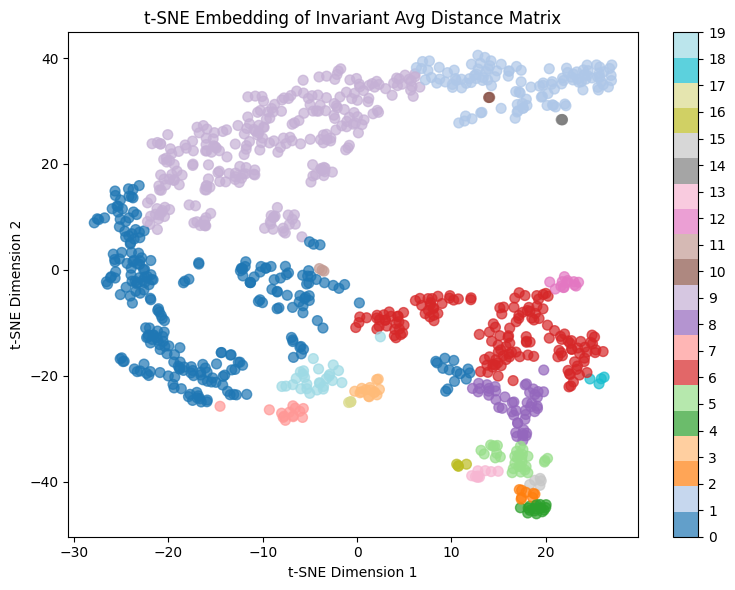

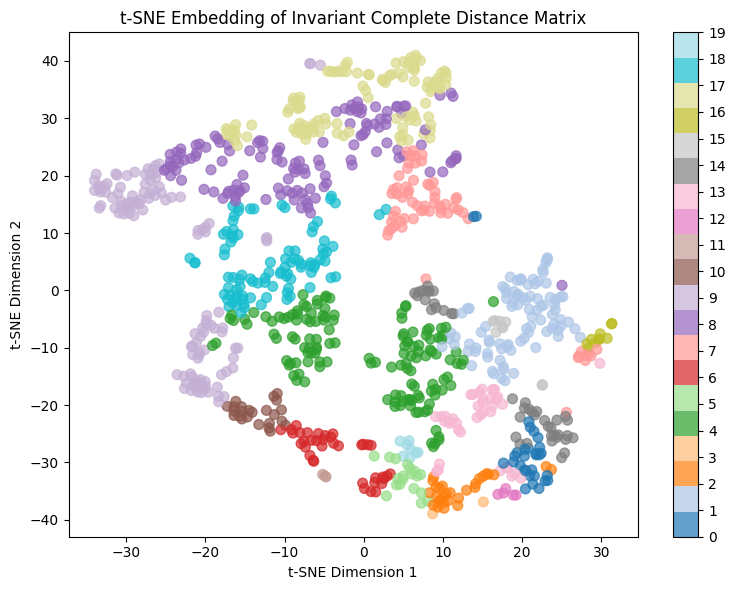

In [ ]:
dist_avg = distance_matrices['invariant_avg_aggregated']
dist_comp = distance_matrices['invariant_complete_aggregated']

labels_avg = hierachial_clustering(dist_avg, n_clusters=20, linkage='average')
labels_comp = hierachial_clustering(dist_comp, n_clusters=20, linkage='complete')

def t_sne_plot(dist_avg, labels_avg, title="t-SNE Embedding of Invariant Avg Distance Matrix", type='average'):
    from sklearn.manifold import TSNE
    tsne = TSNE(metric='precomputed', random_state=42, init='random')
    embedding = tsne.fit_transform(dist_avg)
    
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=labels_avg, cmap='tab20', s=50, alpha=0.7)
    plt.colorbar(scatter, ticks=np.arange(len(set(labels_avg))))
    plt.title(title)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.tight_layout()
    plt.savefig(f"figures/materials/clustering/hierarchical/invariant_features/t_sne_invariant_{type}.png", dpi=300)
    plt.show()

t_sne_plot(dist_avg, labels_avg, title="t-SNE Embedding of Invariant Avg Distance Matrix", type='average')
t_sne_plot(dist_comp, labels_comp, title="t-SNE Embedding of Invariant Complete Distance Matrix", type='complete')

#create_chemiscope_viewer(df, dist_avg, labels_avg, reduction_method='t-SNE')

# import the radar plot from evaluation_pipeline and use it to compare the two clusterings
from scripts.materials_project.evaluation_pipeline import create_radar_plot
create_radar_plot(df, labels_avg, title="Radar Plot - Average Linkage Clustering", filename="figures/materials/clustering/hierarchical/radar_avg.png")
create_radar_plot(df, labels_comp, title="Radar Plot - Complete Linkage Clustering", filename="figures/materials/clustering/hierarchical/radar_comp.png")

In [ ]:
create_chemiscope_viewer(df, dist_avg, labels_avg, reduction_method='t-SNE')

In [10]:
eval_scores = run_evaluation(dist_matrix, linkage=linkage_type) # best number of clusters : ...

Clustering: 100%|██████████| 98/98 [00:02<00:00, 47.10it/s]


In [75]:
n_clusters = 27
metrics = {'sil': [], 'ch': [], 'db': []}
cluster_n_metrics = {key: values[n_clusters-2] for key, values in eval_scores.items()}

hier_labels = hierachial_clustering(dist_matrix, n_clusters=n_clusters, linkage=linkage_type)
random_labels = np.random.randint(0, n_clusters, size=len(df))
chemical_hier_coherence, average_hier_coherence = get_overall_chemical_coherence(df, hier_labels)
chemical_random_coherence, average_random_coherence = get_overall_chemical_coherence(df, random_labels)

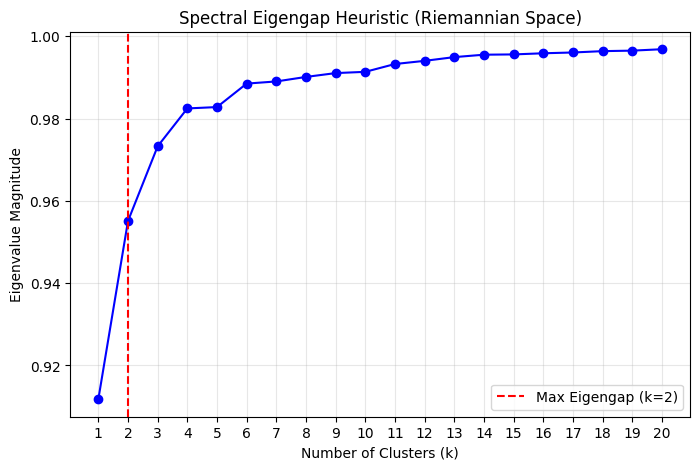

In [ ]:
def find_optimal_k_eigengap(dist_matrix, max_k=20):
    # 1. Convert Riemannian Geodesic Distance to Affinity (Similarity)
    # We use the median distance as a robust bandwidth (sigma) for the Gaussian kernel
    sigma = np.median(dist_matrix)
    affinity_matrix = np.exp(- (dist_matrix ** 2) / (2 * sigma ** 2))
    
    # Optional: Zero out the diagonal (self-similarity)
    np.fill_diagonal(affinity_matrix, 0)

    # 2. Compute the Normalized Graph Laplacian
    L = laplacian(affinity_matrix, normed=True)

    # 3. Compute the eigenvalues
    # We only need the lowest max_k + 2 eigenvalues
    eigenvalues, _ = eigh(L, subset_by_index=[0, max_k + 1])
    
    # 4. Calculate the eigengaps (differences between consecutive eigenvalues)
    # We skip the 0th eigenvalue because it is a mathematical artifact (always ~0)
    gaps = np.diff(eigenvalues)
    
    # The optimal k is the index of the maximum gap
    # We search from index 0 to max_k-1. We add +1 because index 0 corresponds to k=1.
    # We also slice [1:] to avoid trivial k=1 solutions.
    optimal_k = np.argmax(gaps[1:max_k]) + 2 

    # --- Plotting the Eigengap ---
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, max_k + 1), eigenvalues[1:max_k + 1], marker='o', linestyle='-', color='b')
    plt.axvline(x=optimal_k, color='r', linestyle='--', label=f'Max Eigengap (k={optimal_k})')
    plt.title("Spectral Eigengap Heuristic (Riemannian Space)")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Eigenvalue Magnitude")
    plt.xticks(range(1, max_k + 1))
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return optimal_k

dist_matrix = distance_matrices['invariant_riemann']
optimal_k = find_optimal_k_eigengap(dist_matrix)

In [76]:
print("Hierarchical Clustering Coherence:", chemical_hier_coherence)
print("Average Hierarchical Clustering Coherence:", average_hier_coherence)
print("Random Clustering Coherence:", chemical_random_coherence)
print("Average Random Clustering Coherence:", average_random_coherence)

Hierarchical Clustering Coherence: {'band_gap': 0.6003870580904613, 'density': 0.7221332282692695, 'energy_per_atom': 0.7081269127810268, 'formation_energy_per_atom': 0.5880528850534422, 'volume': 0.5416462323869051, 'energy_above_hull': 0.6076866819695352, 'is_metal': 0.723}
Average Hierarchical Clustering Coherence: 0.6415761426500914
Random Clustering Coherence: {'band_gap': 0.5046387979641753, 'density': 0.5070543908156786, 'energy_per_atom': 0.5105246990597965, 'formation_energy_per_atom': 0.5037131027974177, 'volume': 0.5204142983743951, 'energy_above_hull': 0.5856612262368499, 'is_metal': 0.569}
Average Random Clustering Coherence: 0.5287152164640447


In [77]:
create_chemiscope_viewer(df, dist_matrix, hier_labels, reduction_method='t-SNE')

Running t-SNE dimensionality reduction...
Converting Pymatgen structures to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: materials_t-SNE_clustering.json
If the viewer does not open automatically, run `chemiscope show materials_t-SNE_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - SOAP t-SNE Clustering'}, settings={'map': {'x': {'propert…

In [44]:
def plot_coherence_radar(hier_coherence, random_coherence):
    # 1. Extract the features (categories)
    categories = list(hier_coherence.keys())
    
    # 2. Extract the values 
    hier_vals = list(hier_coherence.values())
    random_vals = list(random_coherence.values())
    
    # 3. FIX: Close the loop so the outer line connects back to the start!
    categories.append(categories[0])
    hier_vals.append(hier_vals[0])
    random_vals.append(random_vals[0])
    
    fig = go.Figure()

    # Add Hierarchical Trace
    fig.add_trace(go.Scatterpolar(
        r=hier_vals,
        theta=categories,
        fill='toself',
        name='Hierarchical Clustering',
        line=dict(color='royalblue', width=2),
        fillcolor='rgba(65, 105, 225, 0.3)' # Transparent blue
    ))

    # Add Random Baseline Trace
    fig.add_trace(go.Scatterpolar(
        r=random_vals,
        theta=categories,
        fill='toself',
        name='Random Baseline',
        line=dict(color='crimson', width=2, dash='dot'),
        fillcolor='rgba(220, 20, 60, 0.1)' # Highly transparent red
    ))

    # Layout and Formatting
    fig.update_layout(
        title=dict(
            text='Chemical Coherence Comparison: Hierarchical vs. Random',
            font=dict(size=20),
            y=0.95,
            x=0.5,
            xanchor='center',
            yanchor='top'
        ),
        polar=dict(
            radialaxis=dict(
                visible=True,
                range=[0, 1], # Since your coherence scores are 0 to 1
                tickfont=dict(size=10),
                tickangle=0,
                tickcolor='rgba(0,0,0,0.2)'
            ),
            angularaxis=dict(
                tickfont=dict(size=12, color='black')
            )
        ),
        showlegend=True,
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=-0.15,
            xanchor="center",
            x=0.5
        ),
        template='plotly_white',
        width=700,
        height=700
    )
    
    fig.show()

plot_coherence_radar(chemical_hier_coherence, chemical_random_coherence)

In [13]:
import plotly.graph_objects as go

def plot_normalized_structural_metrics(eval_scores, n_clusters):
    """
    Normalizes the structural metrics for a specific number of clusters 
    relative to all tested configurations, and plots a closed radar chart.
    """
    # If your tests started at n=2, then n_clusters=4 is index 2
    target_index = n_clusters - 2 
    
    categories = []
    normalized_values = []
    raw_values_for_hover = []
    
    # 1. Normalize based on the min/max of the full eval_scores
    for metric_name, values in eval_scores.items():
        val = values[target_index]
        v_min = min(values)
        v_max = max(values)
        
        if v_max == v_min:
            norm_val = 0.5 
        elif metric_name == 'db':
            # DB: Lower is better, so we invert the normalization
            norm_val = (v_max - val) / (v_max - v_min)
            categories.append(f"{metric_name.upper()}<br>(Lower=Better)")
        else:
            # SIL and CH: Higher is better
            norm_val = (val - v_min) / (v_max - v_min)
            categories.append(f"{metric_name.upper()}<br>(Higher=Better)")
            
        normalized_values.append(norm_val)
        raw_values_for_hover.append(val)
        
    # 2. Close the loop for Plotly!
    normalized_values.append(normalized_values[0])
    categories.append(categories[0])
    raw_values_for_hover.append(raw_values_for_hover[0])

    # 3. Create the Plotly Radar Plot
    fig = go.Figure()

    fig.add_trace(go.Scatterpolar(
        r=normalized_values,
        theta=categories,
        fill='toself',
        name=f'{n_clusters} Clusters',
        line=dict(color='darkorange', width=2),
        fillcolor='rgba(255, 140, 0, 0.4)',
        customdata=raw_values_for_hover,
        hovertemplate=(
            "<b>%{theta}</b><br>"
            "Normalized Score: %{r:.2f}<br>"
            "Raw Value: %{customdata:.3f}<extra></extra>"
        )
    ))

    # 4. Layout and Formatting
    fig.update_layout(
        title=dict(
            text=f'Structural Performance: {n_clusters} Clusters (Relative Scale)',
            font=dict(size=18),
            y=0.95,
            x=0.5,
            xanchor='center',
            yanchor='top'
        ),
        polar=dict(
            radialaxis=dict(
                visible=True,
                range=[0, 1],
                tickfont=dict(size=10),
                tickcolor='rgba(0,0,0,0.2)'
            ),
            angularaxis=dict(
                tickfont=dict(size=12, color='black')
            )
        ),
        showlegend=False,
        template='plotly_white',
        width=500,
        height=500
    )
    
    fig.show()

n_clusters = 4
plot_normalized_structural_metrics(eval_scores, n_clusters)